In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import MDS

from toy_disentanglement.task import create_embedding_autoencoder, LatentClassificationDataset, LatentTanhDataset, LatentSinDataset, LatentWaveletDataset
from toy_disentanglement.metrics import classification_generalization_accuracy, regression_generalization_r2

In [2]:
latent_dim = 5

embedding_network = create_embedding_autoencoder(
    input_dim=latent_dim,
    representation_dim=128,
    encoder_hidden_dims=[128,128],
    decoder_hidden_dims=[128,128],
    noise_std=0.0,
    activation="relu",
    train=False,
    num_epochs=4000,
    batch_size=256,
    embedding_type="standard",
    checkpoint_path="data/embedding_nets/embedding_ae_5d_relu_128x2_noiseless.pth"
)

In [4]:
dataset = LatentClassificationDataset(
    latent_dim=latent_dim, 
    num_samples=1000, 
    num_tasks=3, 
    embedding_fn=embedding_network.encoder, 
    bias=False, 
    correlation=0.0, 
    sparsity=0.0, 
    task_correlation=0.0,
)

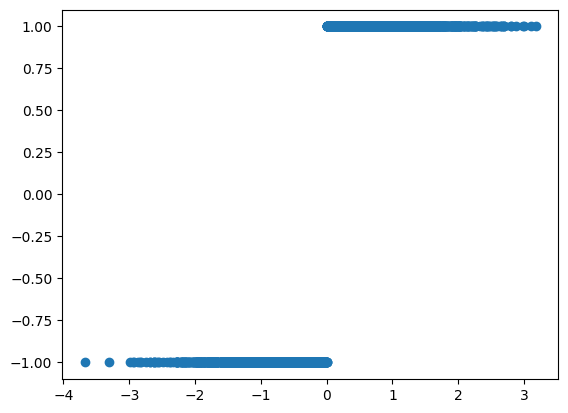

In [6]:
with torch.no_grad():
    x = dataset.latents @ dataset.task_weights + dataset.task_bias
    y = torch.sign(x)
plt.scatter(x, y)

In [24]:
dataset = LatentTanhDataset(
    latent_dim=latent_dim, 
    num_samples=1000, 
    num_tasks=5, 
    embedding_fn=embedding_network.encoder, 
    bias=False, 
    correlation=0.0, 
    sparsity=0.0, 
    task_correlation=0.0,
)

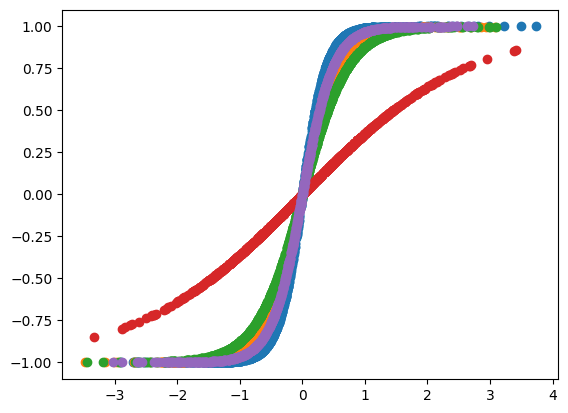

In [25]:
with torch.no_grad():
    x = dataset.latents @ dataset.task_weights + dataset.task_bias
    y = dataset.task_labels
for i in range(x.shape[1]):
    plt.scatter(x[:, i], y[:, i])

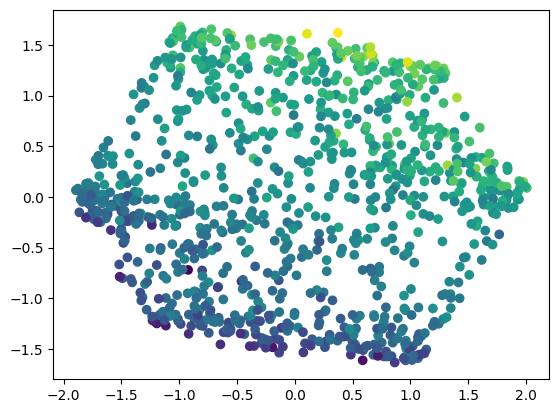

In [32]:
pca = PCA(n_components=2)
y_pca = pca.fit_transform(y)
plt.scatter(y_pca[:, 0], y_pca[:, 1], c=dataset.latents[:, 0])

In [33]:
dataset = LatentSinDataset(
    latent_dim=latent_dim, 
    num_samples=1000, 
    num_tasks=5, 
    embedding_fn=embedding_network.encoder, 
    bias=True, 
    correlation=0.0, 
    sparsity=0.0, 
    task_correlation=0.0,
)

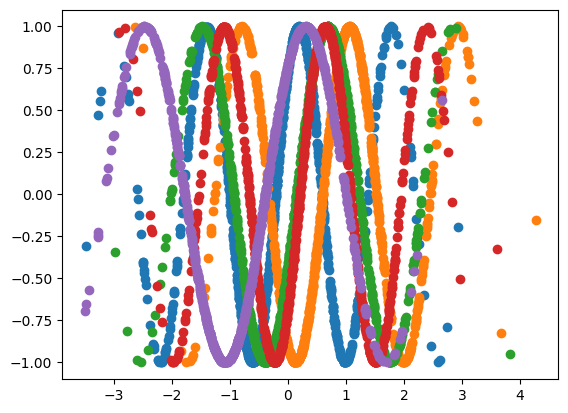

In [34]:
with torch.no_grad():
    x = dataset.latents @ dataset.task_weights + dataset.task_bias
    y = dataset.task_labels
for i in range(x.shape[1]):
    plt.scatter(x[:, i], y[:, i])

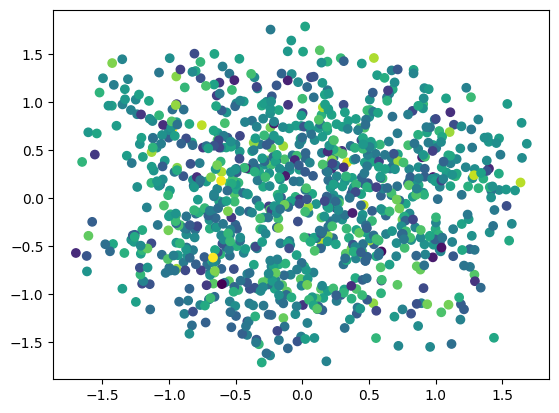

In [35]:
pca = PCA(n_components=2)
y_pca = pca.fit_transform(y)
plt.scatter(y_pca[:, 0], y_pca[:, 1], c=dataset.latents[:, 0])

In [11]:
dataset = LatentWaveletDataset(
    latent_dim=latent_dim, 
    num_samples=1000, 
    num_tasks=10, 
    embedding_fn=embedding_network.encoder, 
    bias=True, 
    correlation=0.0, 
    sparsity=0.0, 
    task_correlation=0.0,
    sin_scale=0.5,
)

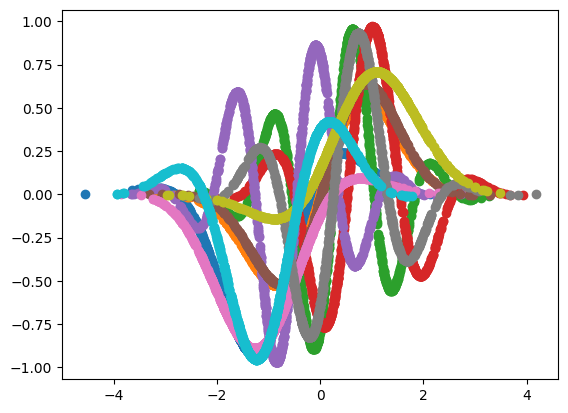

In [12]:
with torch.no_grad():
    x = dataset.latents @ dataset.task_weights + dataset.task_bias
    y = dataset.task_labels
for i in range(x.shape[1]):
    plt.scatter(x[:, i], y[:, i])